In [1]:
using DelimitedFiles, PyPlot


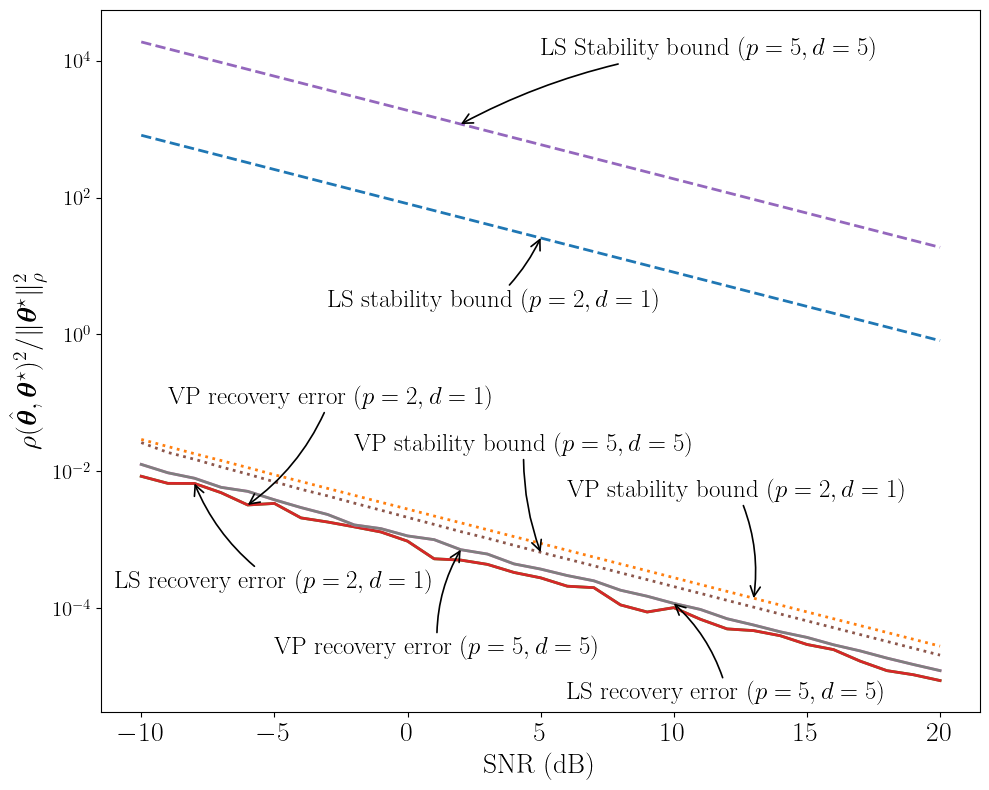

In [2]:
using PyPlot, LaTeXStrings, DelimitedFiles

PyPlot.rc("text", usetex=true)
PyPlot.rc("font", family="serif")
PyPlot.rc("text.latex", preamble = raw"\usepackage{amsmath,amssymb,bm}")

data = readdlm("results/unmixing_stability.csv", ',', skipstart=1)

p      = Int.(data[:,1])
d      = Int.(data[:,2])
snr_db = Float64.(data[:,3])

theory_rel    = Float64.(data[:,11])
theory_rel_vp = Float64.(data[:,12])
rho_ls_rel    = Float64.(data[:,13])
rho_vp_rel    = Float64.(data[:,14])

pairs = unique(zip(p, d))

fig = PyPlot.figure(figsize=(10, 8))
ax  = fig.add_subplot(1,1,1)

# Store line handles + their x/y so we can annotate after plotting
lines = Dict{Tuple{Int,Int,Symbol}, Any}()

for (pi, di) in pairs
    idx = findall((p .== pi) .& (d .== di))
    ord = sortperm(snr_db[idx])
    snr = snr_db[idx][ord]

    l_th,   = ax.plot(snr, theory_rel[idx][ord],    linewidth=2, linestyle="--")
    l_thvp, = ax.plot(snr, theory_rel_vp[idx][ord], linewidth=2, linestyle=":")
    l_ls,   = ax.plot(snr, rho_ls_rel[idx][ord],    linewidth=2)
    l_vp,   = ax.plot(snr, rho_vp_rel[idx][ord],    linewidth=2)

    lines[(pi,di,:theory)]    = (l_th,   snr, theory_rel[idx][ord])
    lines[(pi,di,:theoryvp)]  = (l_thvp, snr, theory_rel_vp[idx][ord])
    lines[(pi,di,:ls)]        = (l_ls,   snr, rho_ls_rel[idx][ord])
    lines[(pi,di,:varpro)]    = (l_vp,   snr, rho_vp_rel[idx][ord])
end

ax.set_xlabel(L"\mathrm{SNR\ (dB)}", fontsize=20)
ax.set_ylabel(L"\rho(\hat{\bm{\theta}}, \bm{\theta}^\star)^2/ \|\bm{\theta}^\star\|_\rho^2", fontsize=20)
ax.set_yscale("log")
# ax.grid(true, which="both", alpha=0.3)

ax.tick_params(axis="x", labelsize=20)
ax.tick_params(axis="y", labelsize=15)

# --- Helper: annotate a curve with an arrow at a chosen SNR (x0) ---
function annotate_curve!(ax, snr::AbstractVector, y::AbstractVector, txt;
                         x0=nothing, i=nothing,
                         dx=-6.0, ymult=2.5,
                         rad=0.15, fs=18)

    # pick index either by explicit i, or nearest to x0
    ii = if i !== nothing
        clamp(i, 1, length(snr))
    elseif x0 !== nothing
        argmin(abs.(snr .- x0))
    else
        max(1, length(snr) - 4)  # near right end by default
    end

    x = snr[ii]
    yy = y[ii]

    ax.annotate(txt,
        xy=(x, yy),
        xytext=(x + dx, yy * ymult),   # multiplicative offset works well on log scale
        textcoords="data",
        fontsize=fs,
        arrowprops=Dict(
            "arrowstyle"=>"->",
            "lw"=>1.2,
            "shrinkA"=>0,
            "shrinkB"=>0,
            "connectionstyle"=>"arc3,rad=$(rad)"
        )
    )
end

# -------------------------
# CHOOSE WHERE TO LABEL
# -------------------------
# Pick ONE (p,d) pair to label (keeps plot clean).
# For your plot, I'd label the higher-dimensional one (p=5,d=5) and let colors/styles imply the other.
pi_lab, di_lab = 5, 5

# Get curves
(_, snr, y_theory)   = lines[(pi_lab, di_lab, :theory)]
(_, _,   y_theoryvp) = lines[(pi_lab, di_lab, :theoryvp)]
(_, _,   y_ls)       = lines[(pi_lab, di_lab, :ls)]
(_, _,   y_vp)       = lines[(pi_lab, di_lab, :varpro)]

# Put arrows at different x locations so they don't stack
annotate_curve!(ax, snr, y_theory,   L"\text{LS Stability bound} \ (p=5,d=5)"; x0=2, dx=3,  ymult=10.2, rad=0.10)
annotate_curve!(ax, snr, y_theoryvp, L"\text{VP stability bound} \ (p=5,d=5)"; x0=5, dx=-7, ymult=30.5, rad=0.10)
annotate_curve!(ax, snr, y_ls,       L"\text{LS recovery error}  \ (p=5,d=5)"; x0=10,  dx=-4, ymult=0.04, rad=0.15)
annotate_curve!(ax, snr, y_vp,       L"\text{VP recovery error}  \ (p=5,d=5)"; x0=2,  dx=-7, ymult=0.03, rad=-0.15)

# If you REALLY want both (p=2,d=1) and (p=5,d=5) labeled,
# repeat the 4 annotate_curve! calls with pi_lab=2, di_lab=1 and use different x0/dx.

(_, snr, y_theory)   = lines[(2, 1, :theory)]
(_, _,   y_theoryvp) = lines[(2, 1, :theoryvp)]
(_, _,   y_ls)       = lines[(2, 1, :ls)]
(_, _,   y_vp)       = lines[(2, 1, :varpro)]

annotate_curve!(ax, snr, y_theory,   L"\text{LS stability bound} \ (p=2,d=1)"; x0=5,   dx=-8, ymult=0.1,  rad=0.10)
annotate_curve!(ax, snr, y_theoryvp, L"\text{VP stability bound} \ (p=2,d=1)"; x0=13,  dx=-7, ymult=30.5, rad=-0.15)
annotate_curve!(ax, snr, y_ls,       L"\text{LS recovery error}  \ (p=2,d=1)"; x0=-8,  dx=-3, ymult=0.03, rad=-0.15)
annotate_curve!(ax, snr, y_vp,       L"\text{VP recovery error}  \ (p=2,d=1)"; x0=-6,  dx=-3, ymult=30.2, rad=-0.15)

PyPlot.tight_layout()

savefig("figures/tsp_stability.pdf", bbox_inches="tight")

fig
